In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_path='housing.csv'
df = pd.read_csv(data_path).dropna()

target='median_house_value'
y=df[target].values
X=df.drop(columns=target)

X=pd.get_dummies(X,drop_first=True).values.astype(float)

n=X.shape[0]

split=int(n*0.8)

X_train, X_test=X[:split],X[split:]
Y_train,Y_test=y[:split],y[split:]

mean=X_train.mean(axis=0)
std=X_train.std(axis=0)+ 1e-8

X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

X_train=np.c_[np.ones(X_train.shape[0]),X_train]
X_test=np.c_[np.ones(X_test.shape[0]),X_test]


In [3]:
#自己设计的回归类，使用Lasso回归(L1)，使用坐标下降法迭代求解
class LinearRegression:
   
    #构造函数
    def __init__(self,alpha=0.1,max_iter=1000,tol=1e-4):
        #L1惩罚强度alpha
        self.alpha=alpha
        #最大迭代轮数
        self.max_iter=max_iter
        #判断是否收敛
        self.tol=tol
        self.theta=None

    #拟合函数
    def fit(self,X,y):
        #获取样本数和特征数
        n_samples,n_features=X.shape
        #先把theta设为零矩阵
        theta=np.zeros(n_features)
        #对每个特征的数据平方求和，对每个特征的更新步长进行归一化，确保不同量纲的特征能够公平地参与迭代，为更新theta做准备
        col_norms=np.sum(X**2,axis=0)

        #开始迭代
        for i in range(self.max_iter):
            #复制上一次迭代的theta,用于本轮迭代
            theta_old=theta.copy()

            #针对每个特征进行处理
            for j in range(n_features):
                #先计算y的预测值
                y_predict=X@theta
                #计算残差
                residual=y-y_predict+theta[j]*X[:,j]

                #定义中间变量rho,用于衡量每个特征和残差的相关度
                rho=X[:,j]@residual
                #处理截据
                if j==0:
                    theta[j]=rho/col_norms[j]
                else:
                    #若rho大于设定的alpha值或小于负的alpha值，说明相关性a较强（正负号表示正相关还是u负相关）
                    if rho>self.alpha:
                        theta[j]=(rho-self.alpha)/col_norms[j]
                    elif rho<-self.alpha:
                        theta[j]=(rho+self.alpha)/col_norms[j]
                    #若rho在正负alpha区间内，说明该特征与残差的相关性不强，直接将其对应的theta值设为0
                    else:
                        theta[j]=0

            #计算变化
            change=np.max(abs(theta-theta_old))
            #看是否收敛
            if change<self.tol:
                break
        self.theta=theta
        return self


    #predict(),score(),mse()函数，同岭回归
    def predict(self,X):
        return X@self.theta

    def score(self,X,y):
        y_predict=self.predict(X)
        ss_residual=np.sum((y-y_predict)**2)
        ss_total=np.sum((y-np.mean(y))**2)
        return 1-ss_residual/ss_total

    def mse(self,X,y):
        return np.mean((y-self.predict(X))**2)

In [4]:
model=LinearRegression().fit(X_train,Y_train)

print(f'Train R^2 = {model.score(X_train, Y_train):.4f}')   
print(f'Test  R^2 = {model.score(X_test, Y_test):.4f}')    
print(f'Test  MSE = {model.mse(X_test, Y_test):.4f}')       
print(f'Test  RMSE = {np.sqrt(model.mse(X_test, Y_test)):.4f}') 


Train R^2 = 0.6279
Test  R^2 = 0.6978
Test  MSE = 4386498488.5697
Test  RMSE = 66230.6461


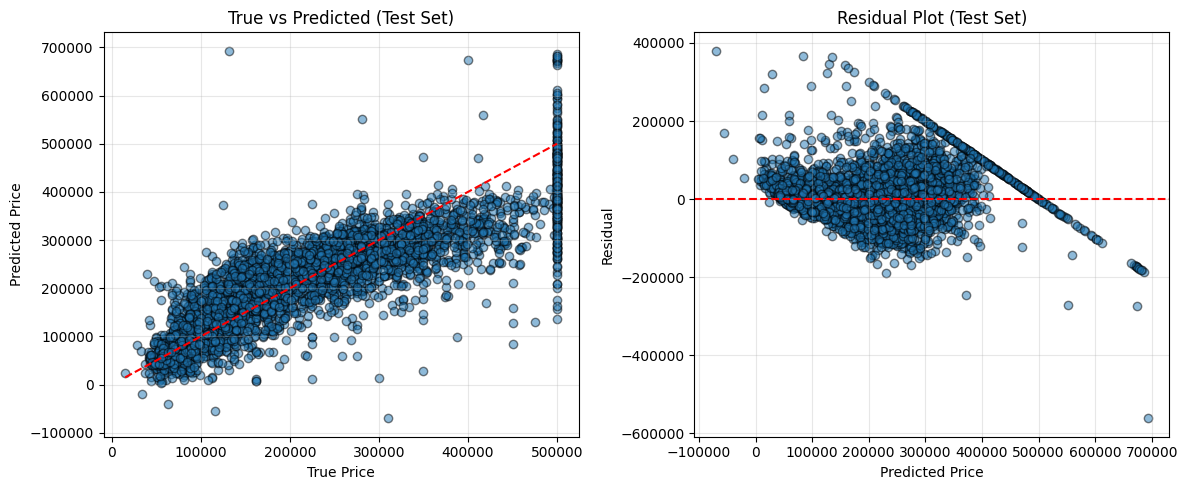

In [5]:
# 4. 画图（可视化评估效果）
# ---------------------------------------
y_pred = model.predict(X_test)           # 得到测试集的预测值
plt.figure(figsize=(12, 5))              # 设置画布大小

# 左图：真实值 vs 预测值 散点图
plt.subplot(1, 2, 1)                     # 1行2列的第1个子图
plt.scatter(Y_test, y_pred, alpha=0.5, edgecolor='k')   # 画散点，alpha控制透明度
plt.plot([Y_test.min(), Y_test.max()], 
         [Y_test.min(), Y_test.max()], 'r--')           # 画对角线（理想情况点都在线上）
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True vs Predicted (Test Set)')
plt.grid(alpha=0.3)                      # 添加半透明网格

# 右图：残差图（真实值-预测值）
plt.subplot(1, 2, 2)                     # 1行2列的第2个子图
residuals = Y_test - y_pred.flatten()    # 计算残差并拉成一维数组
plt.scatter(y_pred.flatten(), residuals, alpha=0.5, edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--')  # 画 y=0 的水平参考线
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot (Test Set)')
plt.grid(alpha=0.3)

plt.tight_layout()                       # 自动调整子图间距防止重叠
plt.show()                               # 显示图形
